# 05 — Synthesis & Implications

Aggregating task-level findings back to the policy-relevant occupation view,
estimating economic magnitudes, and summarizing what the data tells us about
the augmentation-to-automation transition.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import build_task_feature_matrix, load_onet_skills, load_wage_data
from src.features import (
    build_feature_matrix, compute_within_occupation_heterogeneity,
)
from src.model import train_tipping_models, rank_tipping_candidates

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
C = {'auto': '#E63946', 'aug': '#457B9D', 'accent': '#F4A261', 'teal': '#2A9D8F'}

In [2]:
tasks = build_task_feature_matrix()
tasks_unique = tasks.drop_duplicates(subset='task_name').reset_index(drop=True)
occ_features = build_feature_matrix()

print(f"Task-level: {len(tasks_unique):,} unique tasks")
print(f"Occupation-level: {len(occ_features)} quality-filtered occupations")

Task-level: 3,259 unique tasks
Occupation-level: 319 quality-filtered occupations


## Occupation group summary: task-level metrics aggregated up

Instead of the noisy occupation-level automation share, we aggregate the richer
task-level metrics (skill compression, autonomy, success rate) by occupation group.

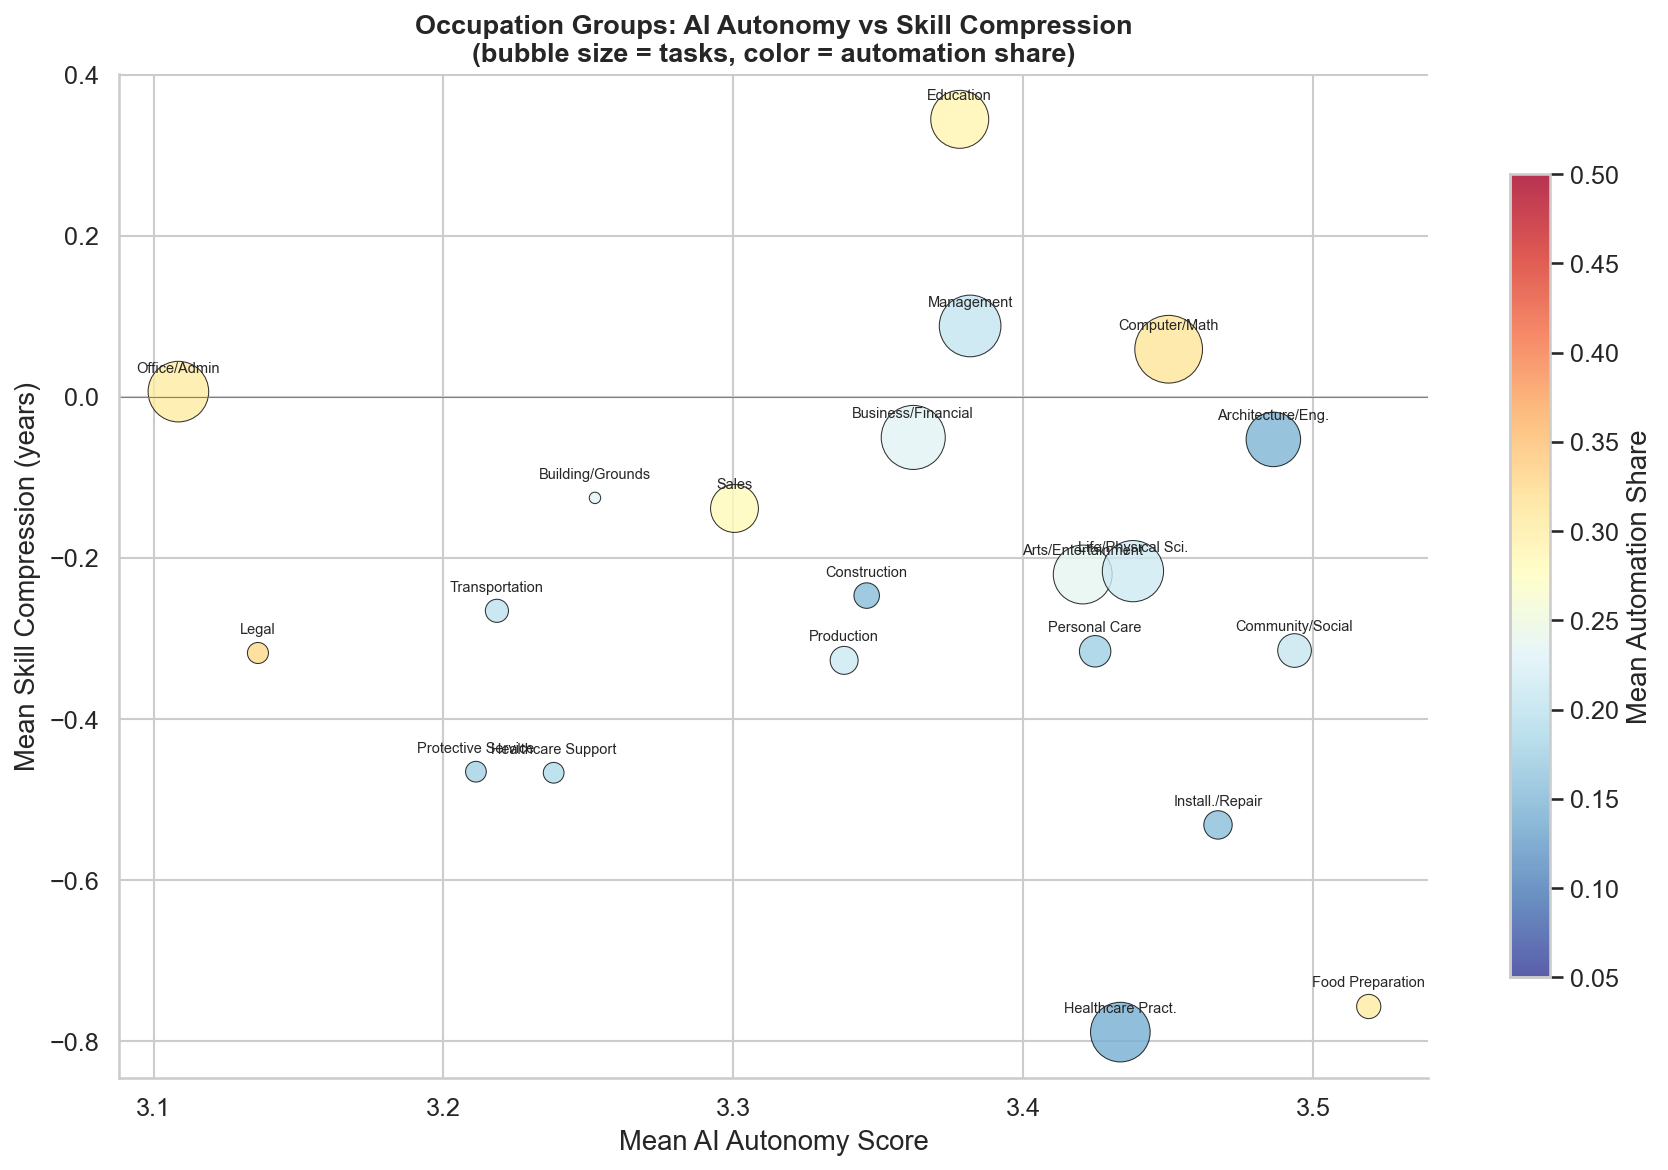

In [3]:
major_group_names = {
    '11': 'Management', '13': 'Business/Financial', '15': 'Computer/Math',
    '17': 'Architecture/Eng.', '19': 'Life/Physical Sci.',
    '21': 'Community/Social', '23': 'Legal', '25': 'Education',
    '27': 'Arts/Entertainment', '29': 'Healthcare Pract.',
    '31': 'Healthcare Support', '33': 'Protective Service',
    '35': 'Food Preparation', '37': 'Building/Grounds',
    '39': 'Personal Care', '41': 'Sales', '43': 'Office/Admin',
    '45': 'Farming/Fishing', '47': 'Construction', '49': 'Install./Repair',
    '51': 'Production', '53': 'Transportation',
}

tasks['group_name'] = tasks['soc_code'].astype(str).str[:2].map(major_group_names)

group_summary = (
    tasks.dropna(subset=['group_name'])
    .groupby('group_name')
    .agg(
        mean_autonomy=('ai_autonomy_mean', 'mean'),
        mean_skill_compression=('skill_compression', 'mean'),
        mean_automation=('automation_share', 'mean'),
        mean_success=('success_rate', 'mean'),
        n_tasks=('task_name', 'nunique'),
    )
    .dropna()
    .query('n_tasks >= 10')
    .sort_values('mean_autonomy', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    group_summary['mean_autonomy'], group_summary['mean_skill_compression'],
    s=group_summary['n_tasks'] * 3, c=group_summary['mean_automation'],
    cmap='RdYlBu_r', alpha=0.8, edgecolors='black', linewidth=0.5,
    vmin=0.05, vmax=0.5,
)
plt.colorbar(scatter, ax=ax, label='Mean Automation Share', shrink=0.8)

for name, row in group_summary.iterrows():
    ax.annotate(name, (row['mean_autonomy'], row['mean_skill_compression']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Mean AI Autonomy Score')
ax.set_ylabel('Mean Skill Compression (years)')
ax.set_title('Occupation Groups: AI Autonomy vs Skill Compression\n(bubble size = tasks, color = automation share)',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/15_group_autonomy_compression.png', bbox_inches='tight')
plt.show()

## Which occupations are most likely shifting toward automation?

Using the occupation-level direction classifier (AUC ~0.71) to rank
currently augmentation-dominant occupations.

Best classifier: RandomForest (AUC = 0.710)


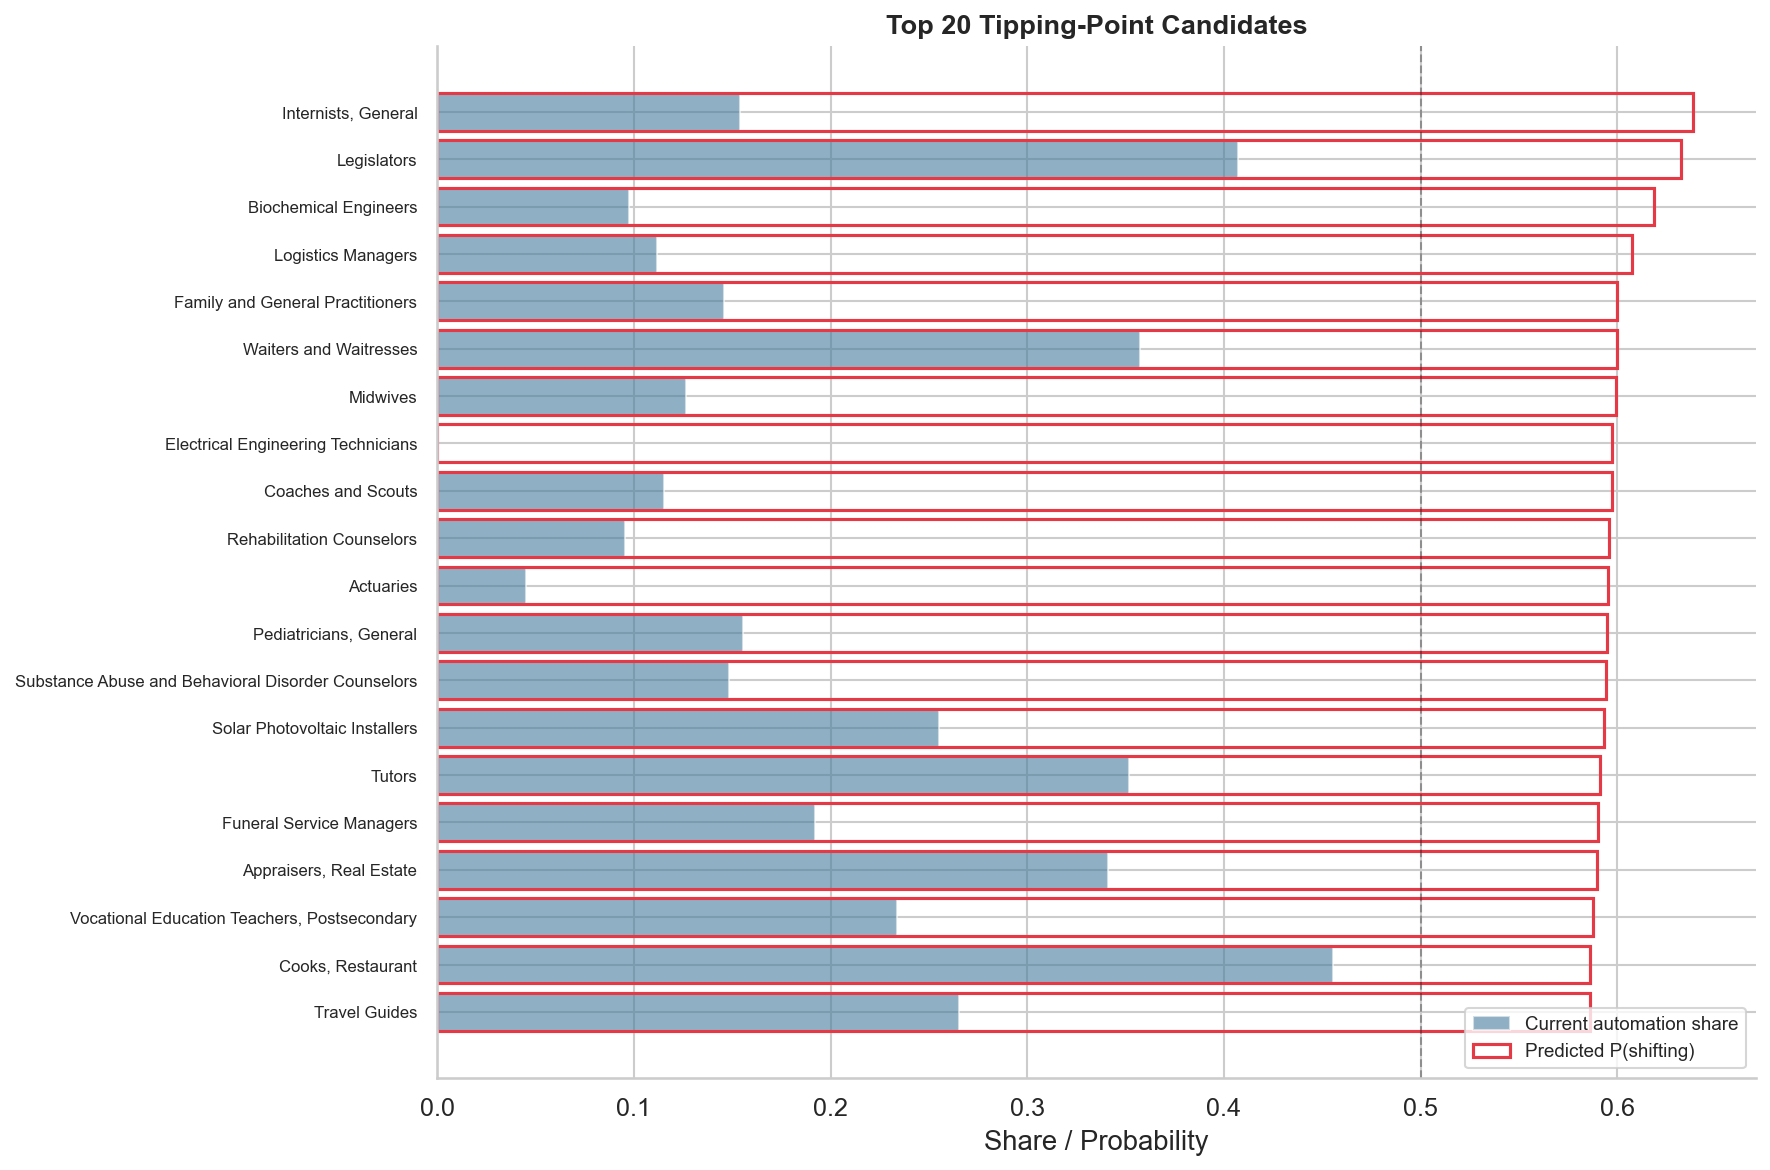

In [4]:
tip_results = train_tipping_models(occ_features)
best_clf = max(tip_results, key=lambda r: r.metrics['auc_cv_mean'])
print(f"Best classifier: {best_clf.name} (AUC = {best_clf.metrics['auc_cv_mean']:.3f})")

ranking = rank_tipping_candidates(occ_features, best_clf)

if not ranking.empty:
    top20 = ranking.head(20).copy()
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(range(len(top20)), top20['latest_automation_share'],
            color=C['aug'], alpha=0.6, label='Current automation share')
    ax.barh(range(len(top20)), top20['predicted_automation_probability'],
            color='none', edgecolor=C['auto'], linewidth=1.5, label='Predicted P(shifting)')
    
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20['title'].values, fontsize=8)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax.set_xlabel('Share / Probability')
    ax.set_title('Top 20 Tipping-Point Candidates',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.invert_yaxis()
    sns.despine()
    plt.tight_layout()
    plt.savefig('../figures/16_tipping_candidates.png', bbox_inches='tight')
    plt.show()

## Full summary

In [5]:
print('The Jagged Adoption Frontier — Summary of Findings')
print('=' * 60)
print(f'Tasks analyzed:           {len(tasks_unique):,}')
print(f'Occupations analyzed:     {len(occ_features)} (quality-filtered)')
print(f'Time window:              Mar 2025 - Mar 2026 (4 releases)')
print()
print('FINDING 1: Signal lives at task level, not occupation level')
print(f'  Task-level AI autonomy R2 (CV):       ~0.29')
print(f'  Occupation-level velocity R2 (CV):    ~0.00')
print(f'  Reason: within-occupation task heterogeneity')
print()
print('FINDING 2: AI Skill Compression predicts automation')
print(f'  Skill compression vs automation share: r=+0.21 (p<1e-33)')
print(f'  Tasks where AI needs less education -> more automation')
print(f'  But: compressed tasks have LOWER autonomy (AI augments, not replaces)')
print()
print('FINDING 3: Platform determines automation mode')
print(f'  API automation premium: ~+25pp over Claude.ai for same task')
print(f'  Across {len(tasks_unique):,} tasks — the channel matters more than the occupation')
print()
print('FINDING 4: The frontier is genuinely jagged')
print(f'  Wage explains <5% of automation variance')
print(f'  O*NET skills provide stronger occupation-level signal')
print()
print('FINDING 5: Task success inversely predicts automation')
print(f'  Success vs automation: r=-0.44 (p<1e-100)')
print(f'  Automated tasks have less human quality control')

The Jagged Adoption Frontier — Summary of Findings
Tasks analyzed:           3,259
Occupations analyzed:     319 (quality-filtered)
Time window:              Mar 2025 - Mar 2026 (4 releases)

FINDING 1: Signal lives at task level, not occupation level
  Task-level AI autonomy R2 (CV):       ~0.29
  Occupation-level velocity R2 (CV):    ~0.00
  Reason: within-occupation task heterogeneity

FINDING 2: AI Skill Compression predicts automation
  Skill compression vs automation share: r=+0.21 (p<1e-33)
  Tasks where AI needs less education -> more automation
  But: compressed tasks have LOWER autonomy (AI augments, not replaces)

FINDING 3: Platform determines automation mode
  API automation premium: ~+25pp over Claude.ai for same task
  Across 3,259 tasks — the channel matters more than the occupation

FINDING 4: The frontier is genuinely jagged
  Wage explains <5% of automation variance
  O*NET skills provide stronger occupation-level signal

FINDING 5: Task success inversely predicts au

---

### What the data says vs. what it doesn't

**It says:**
- The augmentation-to-automation transition is driven by task-level characteristics, not occupation-level averages
- AI skill compression is real: AI reduces education barriers for specific cognitive tasks
- How AI is deployed (API vs interactive) matters far more than where it's deployed
- O*NET skill profiles predict automation patterns better than wage
- Task success and automation are inversely related — automated tasks have less oversight

**It doesn't say:**
- Which specific occupations *will* automate (occupation trajectories are noisy)
- Whether the patterns on Claude generalize to other AI systems
- What the causal mechanisms are (observational data only)
- Whether automation on AI platforms translates to labor market displacement

### Analytical contribution

The key methodological insight: **analyzing AI adoption at the task level reveals signal
that occupation-level aggregation destroys.** The R^2 improvement from 0 to 0.29 by
moving from occupations to tasks demonstrates that the standard approach in AI labor
economics (occupation-level analysis) may be systematically underestimating the
predictability of AI adoption patterns.